In [37]:
import polars as pl
import altair as alt
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import json
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [20]:
#Log files
root = Path('..')
parquet_log = root / 'data/jails-data/output/processing_logs.parquet'
logs_df = pl.read_parquet(parquet_log)
logs_df.group_by("status").len()


status,len
str,u32
"""success""",27333
"""failed""",559


### **Handwritten analysis** 

How many of them are handwritten?

First, we look at the distribution generated by the process:

In [90]:
root = Path('..')
parquet_path = root / 'data/jails-data/output/jails_pdfs.parquet'
df = pl.read_parquet(parquet_path)

In [91]:
ocr_histogram = alt.Chart(df).mark_bar().encode(
    x=alt.X('OCR_Confidence:Q', 
            bin=alt.Bin(maxbins=30),
            title='OCR Confidence Score'),
    y=alt.Y('count():Q', 
            title='Number of Documents'),
    color=alt.value("#7f95ad"),
    tooltip=[
        alt.Tooltip('OCR_Confidence:Q', bin=True, title='OCR Confidence Range'),
        alt.Tooltip('count():Q', title='Document Count')
    ]
).properties(
    width=600,
    height=400,
    title='Distribution of OCR Confidence Scores'
)

vertical_line = alt.Chart(df).mark_rule(
    color='red',
    strokeWidth=2,
    strokeDash=[5, 5]
).encode(
    x=alt.X('OCR_Confidence:Q', scale=alt.Scale(domain=[0, 100]))
).transform_calculate(
    OCR_Confidence='80'
)


ocr_histogram + vertical_line

alt.LayerChart(...)

Total documents with OCR Confidence < 80: 857


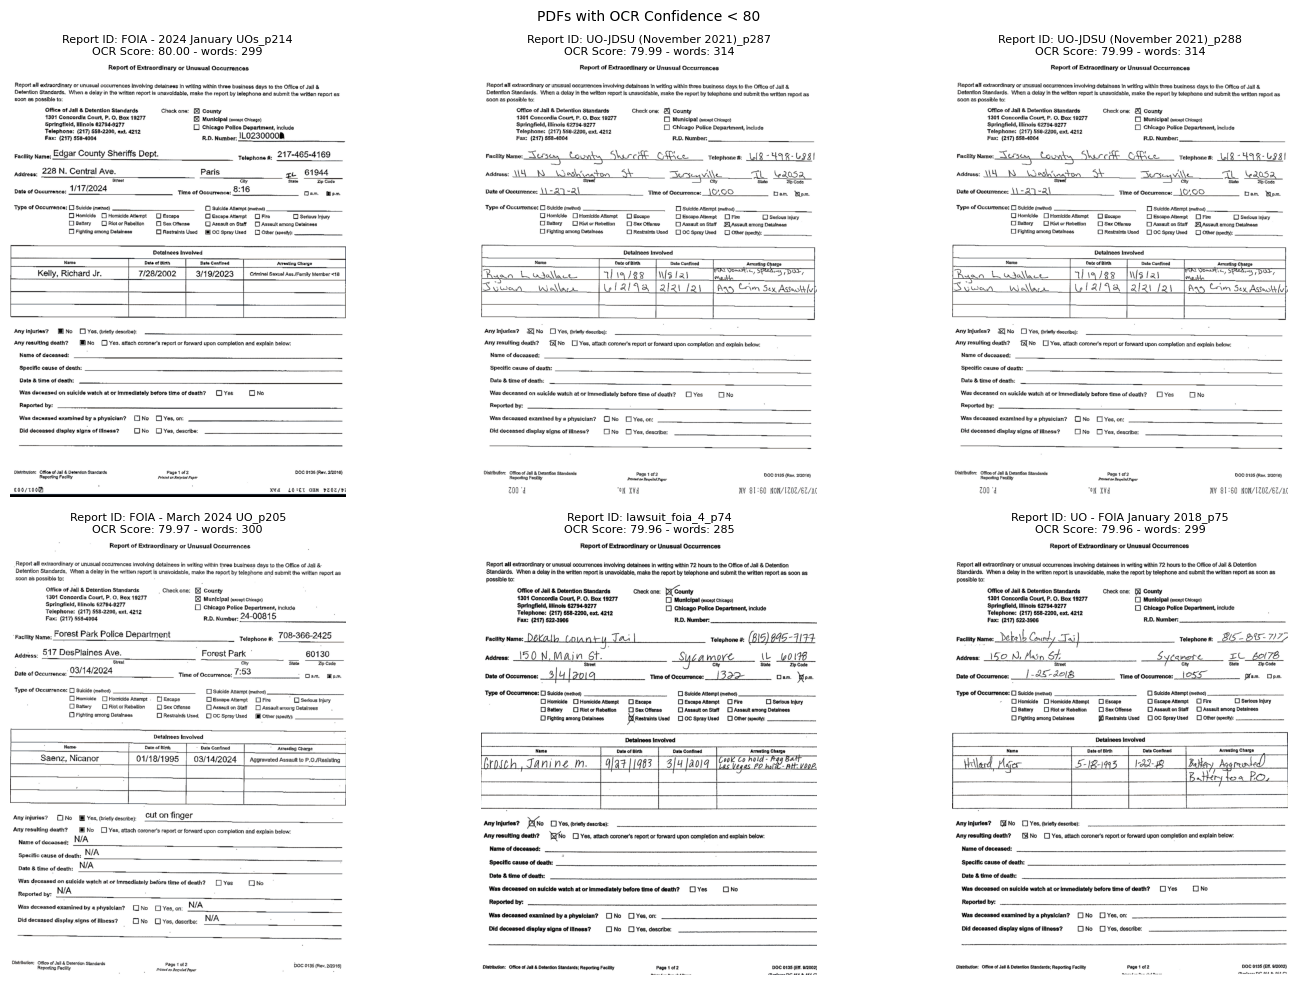

In [93]:
# show the least scores from the ones under 80:
low_ocr_reports = (
    df.filter(pl.col('OCR_Confidence')< 80)
    .select(['Report ID','OCR_Confidence', 'OCR_Word_Count'])
    .sort('OCR_Confidence', descending=True)
    .head(6)
)
# count numer of pages below that
total_pages_threshold = df.filter(pl.col('OCR_Confidence') < 80).height
print(f"Total documents with OCR Confidence < 80: {total_pages_threshold}")
# Folder with images
processed_folder = Path('..') / 'data/jails-data/processed'
# Set up the figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PDFs with OCR Confidence < 80', fontsize=10)

axes = axes.flatten()

for i, row in enumerate(low_ocr_reports.rows()):
    report_id = row[0]
    ocr_score = row[1]
    word_count = row[2]
    img_path = processed_folder / f"{report_id}.png"
    
    pil_image = Image.open(img_path)
    axes[i].imshow(pil_image)
    axes[i].set_title(f'Report ID: {report_id}\nOCR Score: {ocr_score:.2f} - words: {word_count}', fontsize = 8)
    axes[i].axis('off')
for i in range(len(low_ocr_reports), 6):
    axes[i].axis('off')
plt.tight_layout()
plt.show()


In [80]:
# Clean facility name:
def clean_facility_name(df):
    """Clean facility names using Polars expressions"""
    return df.with_columns(
        pl.col('Facility Name')
        # First, clean OCR artifacts
        .str.replace_all(r'\\n|\\\\|\\/', ' ') 
        .str.replace_all(r'\n', ' ')
        .str.replace_all(r'[\\\/]+', ' ')
        .str.replace_all(r'\s+', ' ') 
        .str.strip_chars()
        # Extract facility name after any variation of "Name:"
        .str.extract(r'cility Name:\s*(.+)', 1)
        # Additional cleanup of extracted names
        .str.replace_all(r'[^a-zA-Z\s\'-]', ' ')  # Keep only letters, spaces, apostrophes, hyphens
        .str.replace_all(r'\s+', ' ')  # Clean multiple spaces again
        .str.strip_chars()  # Final trim
        # Stop at any word ending in "ddres" and remove that word + everything after
        .str.replace_all(r'\s+(ddress|ddrace).*$', '')
        .str.replace_all(r"(?i)\bSheriff's\b", "Sheriffs")
        .str.to_titlecase()
        .alias('Cleaned Facility Name')
    )

# Apply the cleaning
df_cleaned = clean_facility_name(df)
df_cleaned['Facility Name', 'Cleaned Facility Name']

Facility Name,Cleaned Facility Name
str,str
"""-acility Name: McHenry County …","""Mchenry County Adult Correctio…"
"""‘acility Name: Kane County She…","""Kane County Sheriffs Office"""
"""Fax: (217) 558-4004 ‘acility N…","""Tei So Ae She Ca Ofce"""
"""‘acility Name: /¥lATTHSOns = o…","""Latthsons Otice Bn Fapameat Tt…"
"""-acility Name: Lake County Adu…","""Lake County Adult Corrections"""
…,…
"""SANs (att) Vee VI ——es- ‘acili…",null
"""Facility Name: Lake County She…","""Lake County Sheriffs Office"""
"""-acility Name: Lake County Jai…","""Lake County Jail"""


In [89]:
# Missing info on facility name
facility_stats = (
    df_cleaned
    .select([
        pl.len().alias('Total'),
        pl.col('Cleaned Facility Name').is_null().sum().alias('Missing'),
    ])
    .with_columns([
        (pl.col('Missing') / pl.col('Total') * 100).alias('Missing_Percent'),
        pl.lit('Cleaned Facility Name').alias('Field')
    ])
    .select(['Field', 'Total','Missing','Missing_Percent'])
)
print("## Facility Name Completeness\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,):
    print(facility_stats)

## Facility Name Completeness

| Field                 | Total | Missing | Missing_Percent |
|-----------------------|-------|---------|-----------------|
| Cleaned Facility Name | 27333 | 2239    | 8.191563        |


In [ ]:
# Most common by facility name
top_facilities = (
    df_cleaned
    .filter(pl.col('Cleaned Facility Name').is_not_null())  # Remove null facility names
    .group_by('Cleaned Facility Name')
    .len()
    .sort('len', descending=True)
    .head(20)
    .rename({'len': 'Case Count'})
)

# Create the Altair chart
facilities_chart = alt.Chart(top_facilities).mark_bar().encode(
    x=alt.X('Case Count:Q', title='Number of Cases'),
    y=alt.Y('Cleaned Facility Name:N', sort='-x', title='Facility Name'),
    color=alt.value("#da746d"), 
    tooltip=[
        'Cleaned Facility Name:N', 
        alt.Tooltip('Case Count:Q', format=',d')
    ]
).properties(
    width=600,
    height=400,
    title='Top 20 Facilities by Number of Cases'
)

facilities_chart

alt.Chart(...)

In [94]:
# Date cleanning
def clean_date_occurrence(df):
    return df.with_columns(
        pl.col("Date")
          # OCR cleanup (keep forward slashes)
          .str.replace_all(r"\\n|\\\\", " ")
          .str.replace_all(r"\n", " ")
          .str.replace_all(r"\s+", " ")
          .str.strip_chars()
          # Extract the MM/DD/YYYY text
          .str.extract(r"Date of Occurrence:\s*([0-9]{1,2}/[0-9]{1,2}/(20[0-9]{2}))", 1)
          # Parse & re‐format to zero‐padded MM/DD/YYYY
          .str.strptime(pl.Date, "%m/%d/%Y", strict=False)
          .alias("temp_date")
    ).with_columns(
        # Only keep dates between 2000 and 2025, otherwise set to null
        pl.when(pl.col("temp_date").dt.year().is_between(2000, 2025))
        .then(pl.col("temp_date").dt.strftime("%m/%d/%Y"))
        .otherwise(None)
        .alias("Cleaned Date")
    ).drop("temp_date")

df_cleaned = clean_date_occurrence(df_cleaned)
df_cleaned.select(["Date","Cleaned Date"]).head(10)

Date,Cleaned Date
str,str
"""Date of Occurrence: 01/09/2021…","""01/09/2021"""
"""Date of Occurrence: 01/27/2021…","""01/27/2021"""
"""aAqaaress. eet o~ SF Never Pat…",null
"""Date of Occurrence: i/ (Z]2 ( …",null
"""Date of Occurrence: 01/15/2021…","""01/15/2021"""
"""Date of Occurrence: 01/14/2021…","""01/14/2021"""
"""Date of Occurrence: 01/19/2021…","""01/19/2021"""
"""Date of Occurrence: 01/13/2021…","""01/13/2021"""
"""AGaress. 14 West STORE SUCCL S…",null


In [95]:
# Calculate cleaned date completeness statistics
date_stats = (
    df_cleaned
    .select([
        pl.len().alias('Total'),
        pl.col('Cleaned Date').is_null().sum().alias('Missing'),
        pl.col('Cleaned Date').is_not_null().sum().alias('Present')
    ])
    .with_columns([
        (pl.col('Missing') / pl.col('Total') * 100).alias('Missing_Percent'),
        pl.lit('Cleaned Date').alias('Field')
    ])
    .select(['Field', 'Total', 'Missing', 'Missing_Percent'])
)

print("## Date Completeness\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,):
    print(date_stats)

## Date Completeness

| Field        | Total | Missing | Missing_Percent |
|--------------|-------|---------|-----------------|
| Cleaned Date | 27333 | 5431    | 19.869755       |


In [96]:
time_series_data = (
    df_cleaned
    .filter(pl.col('Cleaned Date').is_not_null())  # Remove null dates
    .with_columns(
        pl.col('Cleaned Date').str.to_date("%m/%d/%Y").alias('Date_parsed')  # Convert to actual date
    )
    .filter(pl.col('Date_parsed').dt.year().is_between(2018, 2024)) 
    .with_columns(
        pl.col('Date_parsed').dt.truncate('1mo').alias('Month')
    )
    .group_by('Month')
    .len()
    .sort('Month')
    .rename({'len': 'Case Count'})
)

# Create the time series chart
time_series_chart = alt.Chart(time_series_data).mark_line(
    point=True,
    strokeWidth=2
).encode(
    x=alt.X('Month:T', 
            title='Date of Occurrence',
            axis=alt.Axis(format='%b %Y')  # Format as "Jan 2021"
    ),
    y=alt.Y('Case Count:Q', 
            title='Number of Cases'
    ),
    color=alt.value("#50a0d9"),
    tooltip=[
        alt.Tooltip('Month:T', format='%B %d, %Y', title='Date'),
        alt.Tooltip('Case Count:Q', title='Cases')
    ]
).properties(
    width=700,
    height=400,
    title='Cases Over Time - Date of Occurrence'
)

time_series_chart

alt.Chart(...)

In [102]:
# Missing Months from 2018 to 2024 by Facility name:
facility_coverage = (
    df_cleaned
    .filter(
        pl.col('Cleaned Date').is_not_null() &
        pl.col('Cleaned Facility Name').is_not_null()
    )
    .with_columns(
        pl.col('Cleaned Date').str.to_date("%m/%d/%Y").alias('Date_parsed')
    )
    .filter(pl.col('Date_parsed').dt.year().is_between(2018, 2024))
    .with_columns(
        pl.col('Date_parsed').dt.truncate('1mo').alias('Month_Year')
    )
    .group_by(['Cleaned Facility Name', 'Month_Year'])
    .len()
    .group_by('Cleaned Facility Name')
    .agg([
        pl.col('Month_Year').n_unique().alias('Months_With_Data'),
        pl.col('len').sum().alias('Total_Records')
    ])
    .sort(['Months_With_Data', 'Total_Records'], descending=True)
)

print("## Facility Coverage Analysis (2018-2024)\n")
print("**Top 20 Facilities by Month Coverage**\n")
with pl.Config(
    tbl_formatting="MARKDOWN",
    tbl_hide_column_data_types=True,
    tbl_hide_dataframe_shape=True,):
    print(facility_coverage.head(20))


facility_coverage.write_excel('../data/jails-data/output/facility_coverage.xlsx')


## Facility Coverage Analysis (2018-2024)

**Top 20 Facilities by Month Coverage**

| Cleaned Facility Name           | Months_With_Data | Total_Records |
|---------------------------------|------------------|---------------|
| Madison County Sheriffs Office  | 81               | 1222          |
| Sangamon County Jail            | 80               | 633           |
| Kane County Sheriffs Office     | 77               | 1485          |
| Lake County Jail                | 77               | 1133          |
| Sangamon County Adult Detentio… | 74               | 256           |
| …                               | …                | …             |
| Tazewell County Jail            | 50               | 200           |
| Coles County Safety Detention … | 48               | 118           |
| Stephenson County Jail          | 48               | 112           |
| Winnebago County Jail           | 48               | 102           |
| Peoria County Jail              | 46               | 164      

In [97]:
most_common = (df["Table Contents"]
               .explode()
               .value_counts()
               .sort("count", descending=True))

print("Most common Table Contents values:")
most_common.head(10)
#Cehck this

Most common Table Contents values:


Table Contents,count
str,u32
"""VMELAINESs VOW""",6358
"""VElLAINees VvOlIVea""",735
"""Vlas IMVOIVveg""",725
"""(J OC Spray Used""",563
"""Bad parse""",473
"""(1 Fighting among Detainees""",442
"""_] Fighting among Detainees""",424
"""VCldINees IVvVOIVeag""",397
"""(1) OC Spray Used""",374


In [ ]:
#clean_data = []
#for record in raw_data:
#    clean_record = {}
#    for key, value in record.items():
#        if isinstance(value, (dict, list)):
#            clean_record[key] = str(value) 
#        else:
#            clean_record[key] = value
#    clean_data.append(clean_record)


DataFrame has 110 rows and 17 columns
Saved to ../data/jails-data/output/jails_pdfs.parquet


In [98]:
key_fields_s1 = [
    'Facility Name',  'Phone Number', 'Date', 'Address'
]
key_fields_s2 = [
    'Facility Type', 'Time of Day', 'AM or PM'
]
key_fields_s3 = [
    'Table Contents'
]

def get_stats_by_section(sec: int =1):
    
    if sec == 1:
        fields = key_fields_s1
    elif sec == 2:
        fields = key_fields_s2
    elif sec == 3:
        fields = key_fields_s3
    stats = []
    total = df.height

    for field in fields:
        print(field)
        if sec == 3:
           missing_count = df.filter(
               pl.col(field).is_null() |
               (pl.col(field).is_not_null() & (pl.col(field).list.len() == 0))).height
        else: 
        # Count nulls, "N/A", "None", and empty strings
            missing_count = df.filter(
                pl.col(field).is_null() | 
                pl.col(field).eq("N/A") | 
                pl.col(field).eq("None") |
                pl.col(field).eq("")
            ).height
        
        stats.append({
            "Field": field,
            "Missing_Count": missing_count,
            "Missing_Percent": (missing_count / total) * 100,
            "Complete_Count": total - missing_count,
            "Complete_Percent": ((total - missing_count) / total) * 100
        })
        stats_df = pl.DataFrame(stats)
    return stats_df

# Convert stats to DataFrame
stats1 = get_stats_by_section(1)  
stats2 = get_stats_by_section(2)  
stats3 = get_stats_by_section(3)  
stats_df = pl.concat([
    stats1.with_columns(pl.lit("Basic Info").alias("Section")),
    stats2.with_columns(pl.lit("Secondary Info").alias("Section")),
    stats3.with_columns(pl.lit("Table Data").alias("Section"))
])

stats_df.sort("Missing_Percent", descending=True)


Facility Name
Phone Number
Date
Address
Facility Type
Time of Day
AM or PM
Table Contents


Field,Missing_Count,Missing_Percent,Complete_Count,Complete_Percent,Section
str,i64,f64,i64,f64,str
"""Address""",1720,6.29276,25613,93.70724,"""Basic Info"""
"""Facility Name""",766,2.802473,26567,97.197527,"""Basic Info"""
"""Date""",612,2.239052,26721,97.760948,"""Basic Info"""
"""Time of Day""",294,1.075623,27039,98.924377,"""Secondary Info"""
"""Facility Type""",248,0.907328,27085,99.092672,"""Secondary Info"""
"""Phone Number""",223,0.815864,27110,99.184136,"""Basic Info"""
"""Table Contents""",137,0.501226,27196,99.498774,"""Table Data"""
"""AM or PM""",98,0.358541,27235,99.641459,"""Secondary Info"""


In [11]:
missing_chart = alt.Chart(stats_df).mark_bar().encode(
    x=alt.X('Missing_Percent:Q', title='% Missing'),
    y=alt.Y('Field:N', sort='-x', title='Field'),
    color=alt.value('#e45756'),  # Red color for missing
    tooltip=['Field', 'Missing_Count', alt.Tooltip('Missing_Percent:Q', format='.1f')]
).properties(
    width=600,
    title='Percentage of Missing Values by Field'
)

missing_chart

alt.Chart(...)

In [13]:
# Create a stacked bar chart showing complete vs missing
stacked_df = stats_df.unpivot(
    index=["Field"], 
    on=["Complete_Percent", "Missing_Percent"],
    variable_name="Status", 
    value_name="Percentage"
)

# Clean up status names
stacked_df = stacked_df.with_columns(
    pl.col("Status").map_elements(lambda x: "Complete" if "Complete" in x else "Missing")
)

# Create stacked bar chart
stacked_chart = alt.Chart(stacked_df).mark_bar().encode(
    x=alt.X('Percentage:Q', title='Percentage (%)'),
    y=alt.Y('Field:N', title='Field'),
    color=alt.Color('Status:N', scale=alt.Scale(
        domain=['Complete', 'Missing'],
        range=["#94adc7", "#e87e7e"]
    )),
    tooltip=['Field', 'Status', alt.Tooltip('Percentage:Q', format='.1f')]
).properties(
    width=600,
    title='Completion Rate by Field'
)

stacked_chart

/var/folders/m8/p0y07mnx0xj8nxd8l9zj7fn00000gn/T/ipykernel_5420/2304937129.py:10: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  stacked_df = stacked_df.with_columns(


alt.Chart(...)